# Some True Measures

Original QMCPy demo: [`QMCPy/demos/some_true_measures.ipynb`](../../QMCPy/demos/some_true_measures.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/some_true_measures.ipynb)

This notebook adapts QMCPy's `some_true_measures.ipynb` to the Julia `QMC.jl` APIs. The original Python demo focuses on Kumaraswamy, continuous Bernoulli, and Johnson's `S_U`; this Julia version covers those same true measures and also includes several additional `QMC.jl` transforms such as Uniform, Gaussian, StudentT, Triangular, and BrownianMotion.

Parity note: this Julia notebook aligns the shared Kumaraswamy, continuous Bernoulli, and Johnson's `S_U` parameters and expected-value checks first, then labels the added Julia-only transforms such as Uniform, Gaussian, StudentT, Triangular, and BrownianMotion as extensions. The expectation checks use a fixed natural-order digital net for deterministic validation.


## Mathematics

Denote by $f$ the one-dimensional density, $F$ the one-dimensional cumulative distribution function, and $\Psi = F^{-1}$ the inverse CDF transform. When the dimensions are independent, the multivariate true measure is obtained by applying the one-dimensional inverse transform coordinatewise.

For the three measures shared most directly with QMCPy, the transforms are:

- Kumaraswamy: $\Psi(u) = \left(1 - (1-u)^{1/b}\right)^{1/a}$
- Continuous Bernoulli: $\Psi(u) = u$ when $\lambda = 1/2$, with a nonlinear inverse-CDF transform otherwise
- Johnson's $S_U$: $\Psi(u) = \lambda \sinh\!\left(\frac{\Phi^{-1}(u) - \gamma}{\delta}\right) + \xi$

The code below validates these transformations empirically and compares sample statistics to known analytic behavior.

## Imports

The original QMCPy notebook visualizes the shared true measures with 1D and 2D plots and then validates expected values. To keep the Julia demo lightweight, the overlapping measures are summarized with empirical moments plus optional plots when `Plots.jl` is available.


In [1]:
using QMC
using Statistics
using Printf
using SpecialFunctions: gamma

n = 10_000  # samples for empirical statistics

function check_expected_value(tm, exact_mean; abs_tol=1e-5, n=2^20)
    estimate = mean(transform(tm, gen_samples(tm.dd, n))[:, 1])
    @assert abs(estimate - exact_mean) <= abs_tol
    return estimate
end

kumaraswamy_pdf(x, alpha, beta) = alpha * beta * x^(alpha - 1) * (1 - x^alpha)^(beta - 1)
function bernoulli_cont_pdf(x, lambda)
    normalization = 2atanh(1 - 2lambda) / (1 - 2lambda)
    return normalization * lambda^x * (1 - lambda)^(1 - x)
end
function johnsons_su_pdf(x; xi, lambda, gamma, delta)
    z = (x - xi) / lambda
    return delta / (lambda * sqrt(2pi) * sqrt(1 + z^2)) * exp(-0.5 * (gamma + delta * asinh(z))^2)
end
normal_half_pdf(x) = exp(-x^2) / sqrt(pi)

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## 1D Density Plot

When `Plots.jl` is available, the next block overlays histogram-based density views for the shared QMCPy measures.


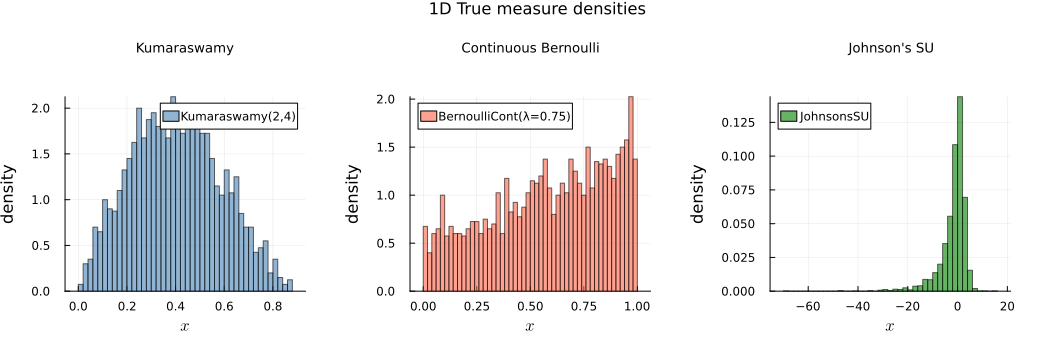

In [2]:
if HAVE_PLOTS
    n_h = 2000
    dd1d = IIDStdUniform(1; seed=7)
    x_gd = LinRange(0, 1, 200)

    # Kumaraswamy
    tm_k = QMC.Kumaraswamy(dd1d; alpha=2.0, beta=4.0)
    xk = transform(tm_k, gen_samples(dd1d, n_h))
    p1 = histogram(xk[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:steelblue, label="Kumaraswamy(2,4)",
        xlabel="\$x\$", ylabel="density", title="Kumaraswamy")

    # Continuous Bernoulli (λ=0.75)
    tm_b = QMC.BernoulliCont(dd1d; lam=0.75)
    xb = transform(tm_b, gen_samples(dd1d, n_h))
    p2 = histogram(xb[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:tomato, label="BernoulliCont(λ=0.75)",
        xlabel="\$x\$", ylabel="density", title="Continuous Bernoulli")

    # Johnson's SU
    tm_j = QMC.JohnsonsSU(dd1d; xi=2.0, lambda=2.0, gamma=1.0, delta=1.0)
    xj = transform(tm_j, gen_samples(dd1d, n_h))
    p3 = histogram(xj[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:green, label="JohnsonsSU",
        xlabel="\$x\$", ylabel="density", title="Johnson's SU")

    display(plot(p1, p2, p3; layout=(1, 3), size=(1050, 340),
        plot_titlevspan=0.12, plot_title="1D True measure densities",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end


## 2D Density Plot

The QMCPy notebook also visualizes higher-dimensional structure. In this Julia notebook, the later plotting block folds those 2D views together with several Julia-only true-measure extensions.


## 1D Expected Values

The next sections cover the true measures that overlap most directly with the QMCPy notebook: Kumaraswamy, Johnson's `S_U`, and continuous Bernoulli. The printed empirical summaries below play the role of the shared one-dimensional expectation checks.


**Kumaraswamy.**


In [3]:
alpha, beta = 2.0, 6.0
kumaraswamy = QMC.Kumaraswamy(DigitalNetB2(1; seed=7, graycode=false); alpha=alpha, beta=beta)
kumaraswamy_mean = beta * gamma(1 + 1 / alpha) * gamma(beta) / gamma(1 + 1 / alpha + beta)
kumaraswamy_estimate = check_expected_value(kumaraswamy, kumaraswamy_mean)
@printf("Kumaraswamy integration within tolerance\n\tEstimated mean: %.4f\n", kumaraswamy_estimate)

Kumaraswamy integration within tolerance
	Estimated mean: 0.3410


**Continuous Bernoulli.**


In [4]:
lambda_cb = 0.75
bernoulli = QMC.BernoulliCont(DigitalNetB2(1; seed=7, graycode=false); lam=lambda_cb)
bernoulli_mean = lambda_cb / (2lambda_cb - 1) + 1 / (2atanh(1 - 2lambda_cb))
bernoulli_estimate = check_expected_value(bernoulli, bernoulli_mean)
@printf("BernoulliCont integration within tolerance\n\tEstimated mean: %.4f\n", bernoulli_estimate)

BernoulliCont integration within tolerance
	Estimated mean: 0.5898


**Johnson's SU.**


In [5]:
gamma_jsu, xi_jsu, delta_jsu, lambda_jsu = 1.0, 2.0, 3.0, 4.0
johnsons_su = QMC.JohnsonsSU(
    DigitalNetB2(1; seed=7, graycode=false);
    gamma=gamma_jsu,
    xi=xi_jsu,
    delta=delta_jsu,
    lambda=lambda_jsu,
)
johnsons_su_mean = xi_jsu - lambda_jsu * exp(1 / (2delta_jsu^2)) * sinh(gamma_jsu / delta_jsu)
johnsons_su_estimate = check_expected_value(johnsons_su, johnsons_su_mean)
@printf("JohnsonsSU integration within tolerance\n\tEstimated mean: %.4f\n", johnsons_su_estimate)

JohnsonsSU integration within tolerance
	Estimated mean: 0.5642


## Importance Sampling with a Single Kumaraswamy

QMCPy expresses this as `Uniform(Kumaraswamy(...))`. Until QMC.jl exposes true-measure composition directly, the equivalent estimator is written explicitly: transform uniform points through the Kumaraswamy inverse CDF and multiply by the inverse proposal density. The target integral is the mean of $g(x)=x$ under the standard uniform measure, namely $1/2$.


Single Kumaraswamy importance estimate: 0.50000000 (exact: 0.5)


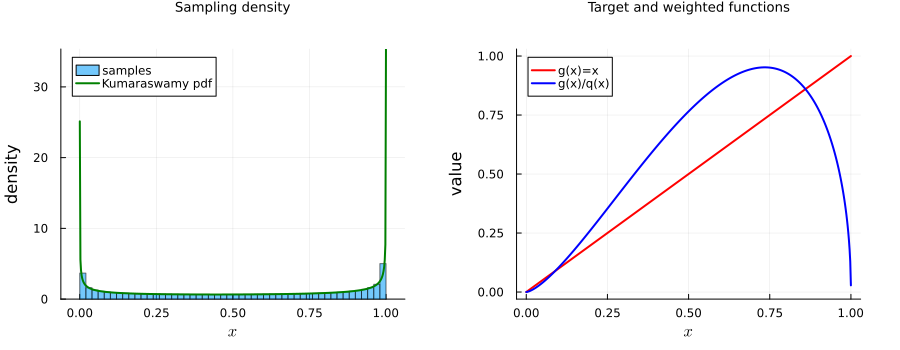

In [6]:
n_is = 2^18
dd_is = DigitalNetB2(1; seed=7, graycode=false)
u_is = gen_samples(dd_is, n_is)
single_alpha, single_beta = 0.5, 0.5
single_tm = QMC.Kumaraswamy(dd_is; alpha=single_alpha, beta=single_beta)
single_samples = transform(single_tm, u_is)
single_density = kumaraswamy_pdf.(single_samples[:, 1], single_alpha, single_beta)
single_values = single_samples[:, 1] ./ single_density
single_estimate = mean(single_values)
@assert abs(single_estimate - 0.5) < 1e-4
@printf("Single Kumaraswamy importance estimate: %.8f (exact: 0.5)\n", single_estimate)

if HAVE_PLOTS
    grid = collect(range(1e-4, 1 - 1e-4; length=500))
    p_density = histogram(single_samples[:, 1]; bins=50, normalize=:pdf, alpha=0.55,
        label="samples", xlabel="\$x\$", ylabel="density", title="Sampling density")
    plot!(p_density, grid, kumaraswamy_pdf.(grid, single_alpha, single_beta);
        color=:green, linewidth=2, label="Kumaraswamy pdf")
    p_function = plot(grid, grid; color=:red, linewidth=2, label="g(x)=x",
        xlabel="\$x\$", ylabel="value", title="Target and weighted functions")
    plot!(p_function, grid, grid ./ kumaraswamy_pdf.(grid, single_alpha, single_beta);
        color=:blue, linewidth=2, label="g(x)/q(x)")
    display(plot(p_density, p_function; layout=(1, 2), size=(900, 350)))
end


## Importance Sampling with 2 (Composed) Kumaraswamys

For two inverse-CDF transforms, the importance weight is the product of their Jacobians. This reproduces QMCPy's composed `Kumaraswamy(Kumaraswamy(...))` experiment without introducing a notebook-only true-measure type.


Composed Kumaraswamy importance estimate: 0.50001492 (exact: 0.5)


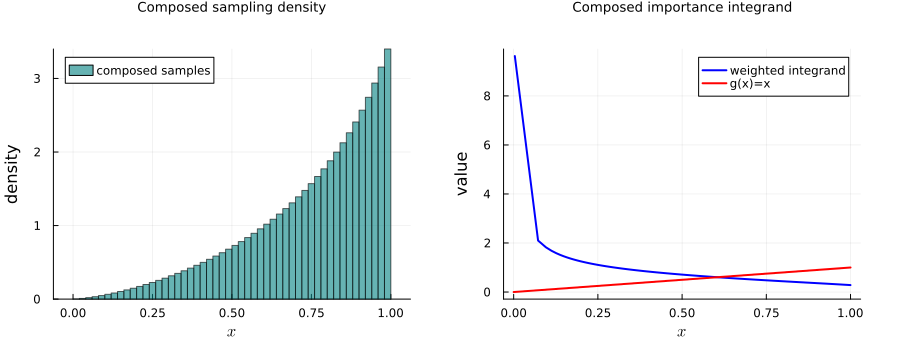

In [7]:
second_alpha, second_beta = 5.0, 2.0
second_tm = QMC.Kumaraswamy(dd_is; alpha=second_alpha, beta=second_beta)
composed_samples = transform(second_tm, single_samples)
second_density = kumaraswamy_pdf.(composed_samples[:, 1], second_alpha, second_beta)
composed_weights = 1.0 ./ (single_density .* second_density)
composed_values = composed_samples[:, 1] .* composed_weights
composed_estimate = mean(composed_values)
@assert abs(composed_estimate - 0.5) < 5e-4
@printf("Composed Kumaraswamy importance estimate: %.8f (exact: 0.5)\n", composed_estimate)

if HAVE_PLOTS
    p_density = histogram(composed_samples[:, 1]; bins=50, normalize=:pdf, alpha=0.6,
        color=:teal, label="composed samples", xlabel="\$x\$", ylabel="density",
        title="Composed sampling density")
    order = sortperm(composed_samples[:, 1])
    stride = max(1, length(order) ÷ 1000)
    selected = order[1:stride:end]
    p_function = plot(composed_samples[selected, 1], composed_values[selected];
        color=:blue, linewidth=2, label="weighted integrand", xlabel="\$x\$", ylabel="value",
        title="Composed importance integrand")
    plot!(p_function, [0, 1], [0, 1]; color=:red, linewidth=2, label="g(x)=x")
    display(plot(p_density, p_function; layout=(1, 2), size=(900, 350)))
end


## Can we Improve the Keister function?

The final shared experiment compares the standard one-dimensional Keister transform with Kumaraswamy, continuous-Bernoulli, and Johnson's $S_U$ proposals. Each estimate includes the exact target-to-proposal density ratio and is checked against `keister_exact(1)`.


Default              estimate: 1.38038848, error: 2.95e-08
Kumaraswamy          estimate: 1.38038847, error: 2.36e-08


Continuous Bernoulli estimate: 1.38039148, error: 3.03e-06
Johnson's SU         estimate: 1.38038845, error: 0.00e+00


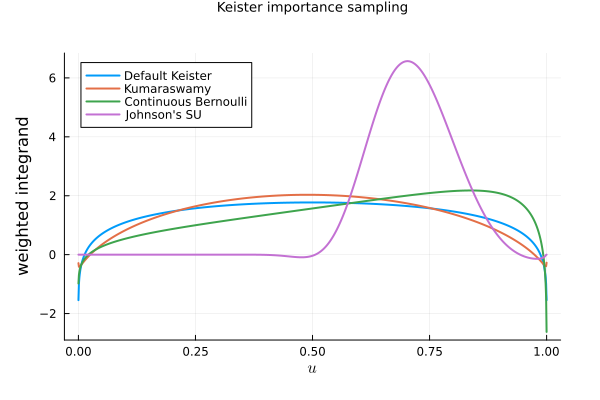

In [8]:
keister_target = keister_exact(1)
gaussian_target = QMC.Gaussian(dd_is; covariance=0.5)
keister = QMC.Keister(gaussian_target)

standard_points = transform(gaussian_target, u_is)
standard_values = evaluate(keister, standard_points)

kuma_alpha, kuma_beta = 0.8, 0.8
kuma_uniform = transform(QMC.Kumaraswamy(dd_is; alpha=kuma_alpha, beta=kuma_beta), u_is)
kuma_points = transform(gaussian_target, kuma_uniform)
kuma_values = evaluate(keister, kuma_points) ./ kumaraswamy_pdf.(kuma_uniform[:, 1], kuma_alpha, kuma_beta)

cb_lambda = 0.25
cb_uniform = transform(QMC.BernoulliCont(dd_is; lam=cb_lambda), u_is)
cb_points = transform(gaussian_target, cb_uniform)
cb_values = evaluate(keister, cb_points) ./ bernoulli_cont_pdf.(cb_uniform[:, 1], cb_lambda)

jsu_parameters = (xi=2.0, lambda=1.0, gamma=2.0, delta=1.0)
jsu_points = transform(QMC.JohnsonsSU(dd_is; jsu_parameters...), u_is)
jsu_proposal = johnsons_su_pdf.(jsu_points[:, 1]; jsu_parameters...)
jsu_values = evaluate(keister, jsu_points) .* normal_half_pdf.(jsu_points[:, 1]) ./ jsu_proposal

keister_estimates = [mean(standard_values), mean(kuma_values), mean(cb_values), mean(jsu_values)]
@assert all(abs.(keister_estimates .- keister_target) .< 1e-4)
for (label, estimate) in zip(["Default", "Kumaraswamy", "Continuous Bernoulli", "Johnson's SU"], keister_estimates)
    @printf("%-20s estimate: %.8f, error: %.2e\n", label, estimate, abs(estimate - keister_target))
end

if HAVE_PLOTS
    u_plot = reshape(collect(range(1e-4, 1 - 1e-4; length=1000)), :, 1)
    standard_curve = evaluate(keister, transform(gaussian_target, u_plot))
    kuma_u_plot = transform(QMC.Kumaraswamy(dd_is; alpha=kuma_alpha, beta=kuma_beta), u_plot)
    kuma_curve = evaluate(keister, transform(gaussian_target, kuma_u_plot)) ./
        kumaraswamy_pdf.(kuma_u_plot[:, 1], kuma_alpha, kuma_beta)
    cb_u_plot = transform(QMC.BernoulliCont(dd_is; lam=cb_lambda), u_plot)
    cb_curve = evaluate(keister, transform(gaussian_target, cb_u_plot)) ./
        bernoulli_cont_pdf.(cb_u_plot[:, 1], cb_lambda)
    jsu_x_plot = transform(QMC.JohnsonsSU(dd_is; jsu_parameters...), u_plot)
    jsu_curve = evaluate(keister, jsu_x_plot) .* normal_half_pdf.(jsu_x_plot[:, 1]) ./
        johnsons_su_pdf.(jsu_x_plot[:, 1]; jsu_parameters...)
    p_keister = plot(u_plot[:, 1], standard_curve; linewidth=2, label="Default Keister",
        xlabel="\$u\$", ylabel="weighted integrand", title="Keister importance sampling")
    plot!(p_keister, u_plot[:, 1], kuma_curve; linewidth=2, label="Kumaraswamy")
    plot!(p_keister, u_plot[:, 1], cb_curve; linewidth=2, label="Continuous Bernoulli")
    plot!(p_keister, u_plot[:, 1], jsu_curve; linewidth=2, label="Johnson's SU")
    display(p_keister)
end


**Julia extensions.**

The remaining sections are Julia-specific extensions beyond the shared QMCPy core. They showcase additional `QMC.jl` true measures such as uniform, Gaussian, Student-t, triangular, and Brownian-motion transforms.


**Uniform.**

In [9]:
println("="^60)
println("Uniform Measure")
println("="^60)

dd = IIDStdUniform(2; seed=7)
tm = QMC.Uniform(dd; lower_bound=-2.0, upper_bound=3.0)
x = gen_samples(dd, n)
xt = transform(tm, x)
@printf("  Range: [%.1f, %.1f], Empirical mean: %.3f (exact: 0.5)\n",
        -2.0, 3.0, mean(xt))
println()

Uniform Measure
  Range: [-2.0, 3.0], Empirical mean: 0.499 (exact: 0.5)



**Gaussian.**

In [10]:
println("="^60)
println("Gaussian Measure")
println("="^60)

dd = IIDStdUniform(2; seed=7)
tm = QMC.Gaussian(dd; mean=0.0, covariance=1.0)
x = gen_samples(dd, n)
xt = transform(tm, x)
@printf("  Standard Normal: mean = %.3f, std = %.3f\n", mean(xt), std(xt))

Gaussian Measure
  Standard Normal: mean = -0.003, std = 0.999


**Custom covariance.**

In [11]:
Σ = [4.0 1.0; 1.0 2.0]
tm2 = QMC.Gaussian(dd; mean=[1.0, -1.0], covariance=Σ)
xt2 = transform(tm2, gen_samples(IIDStdUniform(2; seed=7), n))
@printf("  Custom: mean₁ = %.2f, mean₂ = %.2f (exact: 1, -1)\n",
        mean(xt2[:, 1]), mean(xt2[:, 2]))
println()

  Custom: mean₁ = 0.99, mean₂ = -1.01 (exact: 1, -1)



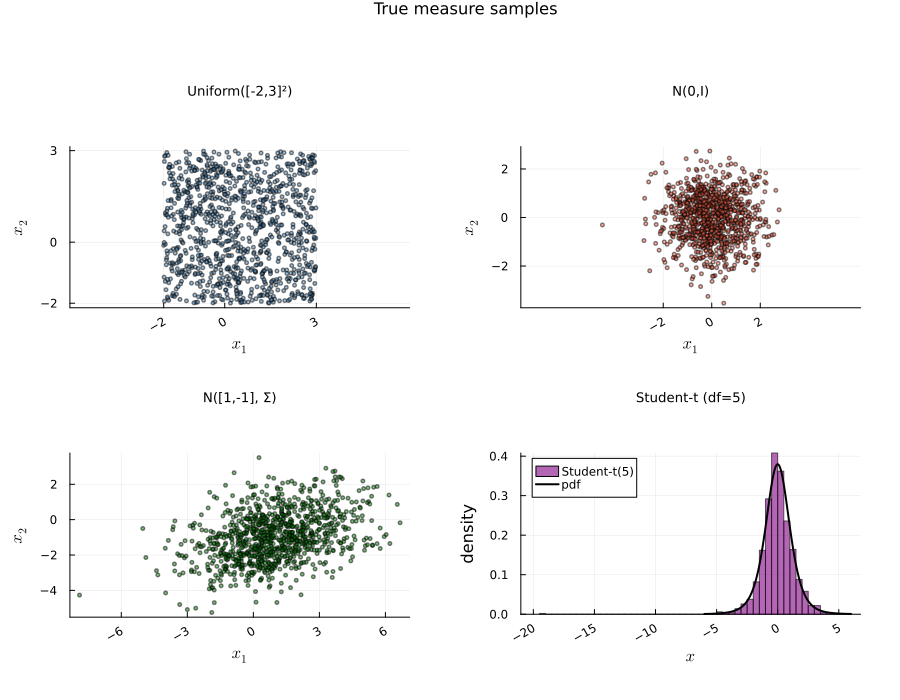

In [12]:
if HAVE_PLOTS
    # Scatter plots of 2D samples from different true measures (regenerated for plotting)
    n_plot = 1000
    dd_plt = IIDStdUniform(2; seed=7)

    # Uniform
    tm_u = QMC.Uniform(dd_plt; lower_bound=-2.0, upper_bound=3.0)
    xu = transform(tm_u, gen_samples(dd_plt, n_plot))
    p1 = scatter(xu[:, 1], xu[:, 2];
        markersize=2, alpha=0.5, color=:steelblue, label=nothing,
        xlabel="\$x_1\$", ylabel="\$x_2\$", title="Uniform([-2,3]²)",
        aspect_ratio=:equal, xticks=[-2, 0, 3], yticks=[-2, 0, 3], xrotation=30)

    # Standard Gaussian
    tm_g = QMC.Gaussian(dd_plt; mean=0.0, covariance=1.0)
    xg = transform(tm_g, gen_samples(IIDStdUniform(2; seed=7), n_plot))
    p2 = scatter(xg[:, 1], xg[:, 2];
        markersize=2, alpha=0.5, color=:tomato, label=nothing,
        xlabel="\$x_1\$", ylabel="\$x_2\$", title="N(0,I)",
        aspect_ratio=:equal, xticks=[-2, 0, 2], yticks=[-2, 0, 2], xrotation=30)

    # Custom Gaussian
    Σ_plt = [4.0 1.0; 1.0 2.0]
    tm_gc = QMC.Gaussian(IIDStdUniform(2; seed=7); mean=[1.0, -1.0], covariance=Σ_plt)
    xgc = transform(tm_gc, gen_samples(IIDStdUniform(2; seed=7), n_plot))
    p3 = scatter(xgc[:, 1], xgc[:, 2];
        markersize=2, alpha=0.5, color=:green, label=nothing,
        xlabel="\$x_1\$", ylabel="\$x_2\$", title="N([1,-1], Σ)", xrotation=30)

    # Student-t (1D histogram each dim)
    using Distributions: TDist, pdf
    dd1 = IIDStdUniform(1; seed=7)
    tm_t = QMC.StudentT(dd1; df=5.0)
    xt_plt = transform(tm_t, gen_samples(dd1, n_plot))
    x_grid = LinRange(-6, 6, 200)
    p4 = histogram(xt_plt[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:purple, label="Student-t(5)",
        xlabel="\$x\$", ylabel="density", title="Student-t (df=5)", xrotation=30)
    plot!(x_grid, pdf.(TDist(5), collect(x_grid)); color=:black, lw=2, label="pdf")

    display(plot(p1, p2, p3, p4; layout=(2,2), size=(900, 700),
        plot_titlevspan=0.12, plot_title="True measure samples",
        top_margin=10Plots.mm, bottom_margin=8Plots.mm))
end


**Student-t.**

In [13]:
println("="^60)
println("Student-t Measure")
println("="^60)

for df in [2.0, 5.0, 30.0]
    local dd, tm, x, xt
    dd = IIDStdUniform(1; seed=7)
    tm = QMC.StudentT(dd; df=df)
    x = gen_samples(dd, n)
    xt = transform(tm, x)
    theoretical_var = df > 2 ? df / (df - 2) : Inf
    @printf("  df = %4.0f: mean = %+.3f, var = %6.3f (exact var = %.3f)\n",
            df, mean(xt), var(xt), theoretical_var)
end
println()

Student-t Measure
  df =    2: mean = -0.067, var = 21.737 (exact var = Inf)
  df =    5: mean = -0.012, var =  1.648 (exact var = 1.667)
  df =   30: mean = -0.008, var =  1.068 (exact var = 1.071)



**Triangular.**

In [14]:
println("="^60)
println("Triangular Measure")
println("="^60)

dd = IIDStdUniform(1; seed=7)
tm = QMC.Triangular(dd; lower=0.0, upper=1.0, mode=0.5)
x = gen_samples(dd, n)
xt = transform(tm, x)
exact_mean = (0.0 + 1.0 + 0.5) / 3.0
@printf("  Triangular(0, 1, 0.5): mean = %.4f (exact = %.4f)\n",
        mean(xt), exact_mean)

tm2 = QMC.Triangular(dd; lower=-1.0, upper=2.0, mode=1.5)
xt2 = transform(tm2, gen_samples(IIDStdUniform(1; seed=7), n))
exact_mean2 = (-1.0 + 2.0 + 1.5) / 3.0
@printf("  Triangular(-1, 2, 1.5): mean = %.4f (exact = %.4f)\n",
        mean(xt2), exact_mean2)
println()

Triangular Measure
  Triangular(0, 1, 0.5): mean = 0.4987 (exact = 0.5000)
  Triangular(-1, 2, 1.5): mean = 0.8289 (exact = 0.8333)


**Brownian Motion.**

In [15]:
println("="^60)
println("Brownian Motion Measure")
println("="^60)

dd = IIDStdUniform(8; seed=7)
tm = QMC.BrownianMotion(dd; drift=0.0)
x = gen_samples(dd, n)
paths = transform(tm, x)
@printf("  d=8 timesteps, n=%d paths\n", n)
@printf("  E[W(T)] = %.3f (exact = 0)\n", mean(paths[:, end]))
@printf("  Var[W(T)] = %.3f (exact = 1)\n", var(paths[:, end]))

Brownian Motion Measure
  d=8 timesteps, n=10000 paths
  E[W(T)] = -0.006 (exact = 0)


  Var[W(T)] = 0.996 (exact = 1)


**With drift.**

In [16]:
tm_d = QMC.BrownianMotion(dd; drift=0.1)
paths_d = transform(tm_d, gen_samples(IIDStdUniform(8; seed=7), n))
@printf("  With drift 0.1: E[W(T)] = %.3f (exact = 0.1)\n", mean(paths_d[:, end]))
println()

println("="^60)
println("True measures demo completed!")

  With drift 0.1: E[W(T)] = 0.094 (exact = 0.1)

True measures demo completed!


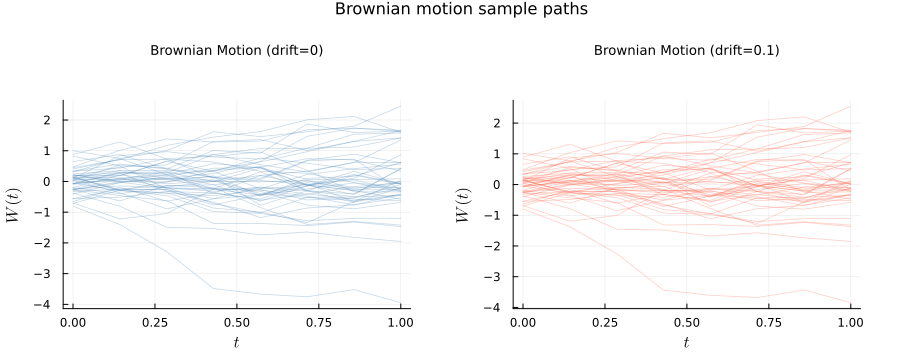

In [17]:
if HAVE_PLOTS
    n_bm = 200
    d_bm = 8
    dd_bm = IIDStdUniform(d_bm; seed=7)
    tm_bm0 = QMC.BrownianMotion(dd_bm; drift=0.0)
    tm_bm1 = QMC.BrownianMotion(dd_bm; drift=0.1)
    bm0 = transform(tm_bm0, gen_samples(dd_bm, n_bm))   # n_bm × d_bm
    bm1 = transform(tm_bm1, gen_samples(IIDStdUniform(d_bm; seed=7), n_bm))
    t_bm = LinRange(0, 1, d_bm)

    p1 = plot(t_bm, bm0[1:50, :]';
        alpha=0.3, color=:steelblue, lw=0.8, label=nothing,
        xlabel="\$t\$", ylabel="\$W(t)\$", title="Brownian Motion (drift=0)")
    p2 = plot(t_bm, bm1[1:50, :]';
        alpha=0.3, color=:tomato, lw=0.8, label=nothing,
        xlabel="\$t\$", ylabel="\$W(t)\$", title="Brownian Motion (drift=0.1)")
    display(plot(p1, p2; layout=(1, 2), size=(900, 360),
        plot_titlevspan=0.12, plot_title="Brownian motion sample paths",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end
